In [1]:
import networkx as nx
import pandas as pd
import matplotlib.pyplot as plt

Creating the graph:

In [2]:
edges_df = pd.read_csv("../word-graph/word_graph_edges_list.csv") 

# Creating a nodes list
nodes_list = set(e for e in edges_df['Source'])
for e in edges_df['Target']:
    nodes_list.add(e)
nodes_list = list(nodes_list)

G = nx.Graph() 

G.add_nodes_from(nodes_list)

# Add edges with weight
for _, row in edges_df.iterrows():
    G.add_edge(row['Source'], row['Target'], weight=row['Weight'])

In [3]:
len(nodes_list)

187

Checking if the graph is connected:

In [4]:
if nx.is_connected(G):
    print ("The graph is connected")
else:
    print ("The graph is not connected")

The graph is not connected


In [5]:
largest_cc = max(nx.connected_components(G), key=len)
G_sub = G.subgraph(largest_cc)
diameter = nx.diameter(G_sub)
print("Graph's biggest component diameter:", diameter)

Graph's biggest component diameter: 7


In [6]:
density = nx.density(G)
print("Graph's density", density)

Graph's density 0.028808004140072452


In [7]:
bridges = list(nx.bridges(G))

print("Number of bridges:", len(bridges))
print("Bridges:", bridges)

Number of bridges: 51
Bridges: [('die', 'day'), ('wake', 'bed'), ('stick', 'round'), ('bitch', 'foot'), ('bitch', 'talk'), ('bitch', 'fuckin'), ('street', 'bar'), ('night', 'thinkin'), ('night', 'remember'), ('burn', 'smoke'), ('waste', 'time'), ('man', 'city'), ('feel', 'air'), ('wish', 'good'), ('hear', 'think'), ('help', 'act'), ('crash', 'stop'), ('floor', 'dance'), ('door', 'open'), ('see', 'love'), ('drive', 'car'), ('believe', 'baby'), ('daddy', 'forget'), ('big', 'love'), ('good', 'reason'), ('step', 'way'), ('fast', 'car'), ('block', 'say'), ('watch', 'away'), ('pass', 'time'), ('fun', 'girl'), ('place', 'okay'), ('whiskey', 'shot'), ('low', 'high'), ('real', 'love'), ('love', 'trust'), ('love', 'keep'), ('love', 'pain'), ('pour', 'drink'), ('pour', 'damn'), ('wonder', 'tired'), ('high', 'road'), ('forever', 'well'), ('time', 'cold'), ('late', 'well'), ('damn', 'round'), ('stop', 'beat'), ('young', 'baby'), ('pretty', 'little'), ('blame', 'baby'), ('red', 'wine')]


In [8]:
articulation_points = list(nx.articulation_points(G))

print("Number of articulation points:", len(articulation_points))
print("Articulation points:", articulation_points)

Number of articulation points: 33
Articulation points: ['feel', 'away', 'good', 'girl', 'burn', 'dance', 'little', 'okay', 'tired', 'bed', 'whiskey', 'stop', 'bitch', 'bar', 'man', 'well', 'say', 'help', 'way', 'high', 'road', 'night', 'time', 'door', 'baby', 'day', 'love', 'think', 'thing', 'pour', 'damn', 'round', 'car']


In [9]:
degree_centrality = nx.degree_centrality(G)
betweenness_centrality = nx.betweenness_centrality(G)
closeness_centrality = nx.closeness_centrality(G)

In [10]:
print("Top 5 by degree centrality:", sorted(degree_centrality.items(), key=lambda x: x[1], reverse=True)[:5])
print("Top 5 by betweenness centrality:", sorted(betweenness_centrality.items(), key=lambda x: x[1], reverse=True)[:5])
print("Top 5 by closeness centrality:", sorted(closeness_centrality.items(), key=lambda x: x[1], reverse=True)[:5])

Top 5 by degree centrality: [('love', 0.34408602150537637), ('baby', 0.25268817204301075), ('think', 0.1774193548387097), ('good', 0.15591397849462366), ('night', 0.13978494623655915)]
Top 5 by betweenness centrality: [('love', 0.2980741280632419), ('baby', 0.17069842690700307), ('good', 0.11009727614429134), ('way', 0.06511713960474186), ('bitch', 0.06327873792379143)]
Top 5 by closeness centrality: [('love', 0.5425806451612902), ('baby', 0.49028371550718997), ('think', 0.44965246836571016), ('say', 0.44352641293838446), ('good', 0.4411224757408864)]


In [11]:
from networkx.algorithms.community import girvan_newman
from networkx.algorithms.community.quality import modularity
import itertools

In [12]:

# Check modularity for each number of communities created by slicing the graph

comp = girvan_newman(G)

modularities = []
num_communities = []
partitions = []

for i, communities in enumerate(itertools.islice(comp, 20), start=1):  # Try up to 21 communities
    communities = tuple(sorted(c) for c in communities)
    mod = modularity(G, communities)
    
    modularities.append(mod)
    num_communities.append(len(communities))
    partitions.append(communities)

    print(f"{len(communities)} communities → Modularity: {mod:.4f}")

6 communities → Modularity: 0.0408
7 communities → Modularity: 0.0743
8 communities → Modularity: 0.0804
9 communities → Modularity: 0.1074
10 communities → Modularity: 0.1186
11 communities → Modularity: 0.1202
12 communities → Modularity: 0.2336
13 communities → Modularity: 0.2449
14 communities → Modularity: 0.2540
15 communities → Modularity: 0.2594
16 communities → Modularity: 0.2590
17 communities → Modularity: 0.2588
18 communities → Modularity: 0.2630
19 communities → Modularity: 0.2627
20 communities → Modularity: 0.2624
21 communities → Modularity: 0.2620
22 communities → Modularity: 0.2613
23 communities → Modularity: 0.2606
24 communities → Modularity: 0.2603
25 communities → Modularity: 0.2600


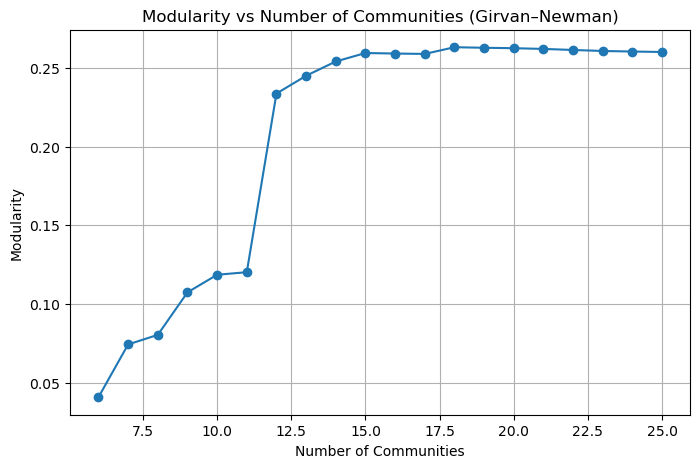

In [13]:
plt.figure(figsize=(8, 5))
plt.plot(num_communities, modularities, marker='o')
plt.xlabel("Number of Communities")
plt.ylabel("Modularity")
plt.title("Modularity vs Number of Communities (Girvan–Newman)")
plt.grid(True)
plt.show()

In [14]:
# continue partitioning for best modularity

best_index = modularities.index(max(modularities))
best_partition = partitions[best_index]

In [15]:
# Assign community index to each node
community_map = {}
for i, community in enumerate(best_partition):
    for node in community:
        community_map[node] = i

# Add it as a node attribute in the graph
nx.set_node_attributes(G, community_map, "modularity_class")

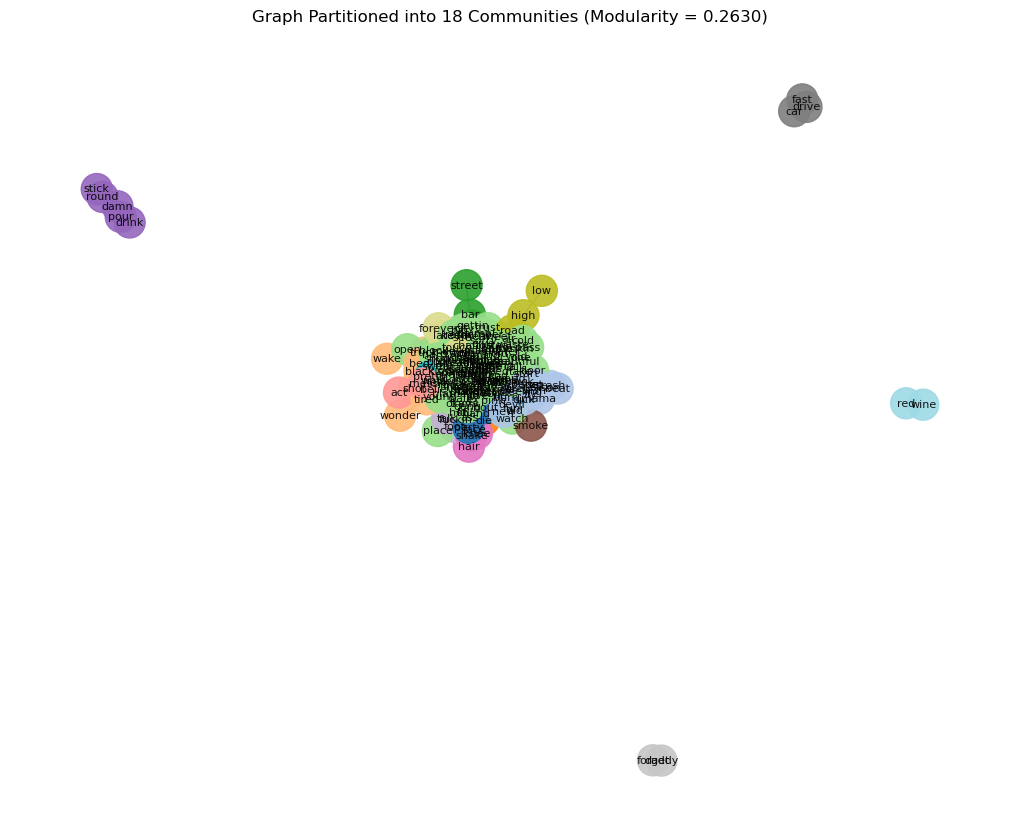

In [16]:
# Draw the graph with colors
pos = nx.spring_layout(G, k=0.6, iterations=100, seed=42)
cmap = plt.get_cmap('tab20', len(best_partition))

plt.figure(figsize=(10, 8))
nx.draw(
    G,
    pos,
    node_color=[community_map[n] for n in G.nodes()],
    cmap=cmap,
    with_labels=True,
    node_size=500,
    font_size=8,
    edge_color='gray',
    alpha=0.9
)
plt.title(f"Graph Partitioned into {len(best_partition)} Communities (Modularity = {max(modularities):.4f})")
plt.show()

In [38]:
# Export to gephi

nx.write_gexf(G, "word_graph_partitioned.gexf")